In [1]:
# ═══════════════════════════════════════════════
# CELL 1: Imports & Setup
# ═══════════════════════════════════════════════
!pip install -q timm
import timm
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader

import pandas as pd
import numpy as np
from PIL import Image
from pathlib import Path
from tqdm import tqdm
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, os

warnings.filterwarnings('ignore')
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 11})

print("All imports loaded")


All imports loaded


In [2]:
# ═══════════════════════════════════════════════
# CELL 2: GPU Check
# ═══════════════════════════════════════════════
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU   : {torch.cuda.get_device_name(0)}")
    print(f"VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")


Device: cuda
GPU   : Tesla P100-PCIE-16GB
VRAM  : 15.9 GB


In [3]:
# ═══════════════════════════════════════════════
# CELL 3: Config — Updated for retrained models
# ═══════════════════════════════════════════════

DATA_ROOT  = Path("/kaggle/input/datasets/ashery/chexpert")
VALID_CSV  = DATA_ROOT / "valid.csv"
IMAGE_ROOT = DATA_ROOT
BATCH_SIZE = 32
NUM_CLASSES = 14

LABEL_NAMES = [
    "No Finding", "Enlarged Cardiomediastinum", "Cardiomegaly",
    "Lung Opacity", "Lung Lesion", "Edema", "Consolidation",
    "Pneumonia", "Atelectasis", "Pneumothorax", "Pleural Effusion",
    "Pleural Other", "Fracture", "Support Devices"
]

# ── Per-model image sizes (CRITICAL — EfficientNet-B3 uses 300, not 224) ──
IMAGE_SIZES = {
    "ResNet50"       : 224,
    "DenseNet-121"   : 224,
    "EfficientNet-B3": 300,   # ← trained at 300x300
    "ViT-B16"        : 224,
}

# ── Updated checkpoint paths — point to your NEW retrained .pth files ──
# Attach each retrain notebook as a Kaggle input to get these paths
CHECKPOINTS = {
    "ResNet50": (
        "/kaggle/input/notebooks/d1nushi/"
        "final-train-resnet50/best_resnet50.pth"
    ),

    # ← CHANGED: now points to your uploaded dataset, not a notebook output
    "DenseNet-121": (
        "/kaggle/input/datasets/ravinduwellalage2/densenet121-chexpert-checkpoint/"
        "best_densenet121.pth"
    ),

    "EfficientNet-B3": (
        "/kaggle/input/notebooks/ravinduwellalage2/"
        "final-train-efficientnet-b3/best_efficientnet_b3.pth"
    ),

    "ViT-B16": (
        "/kaggle/input/notebooks/d1nushi/"
        "final-train-vit-b16/best_vit_b16.pth"
    ),
}

AVAILABLE = {k: v for k, v in CHECKPOINTS.items() if Path(v).exists()}
MISSING    = {k: v for k, v in CHECKPOINTS.items() if not Path(v).exists()}

print("=" * 60)
print("CHECKPOINT STATUS")
print("=" * 60)
for m, p in AVAILABLE.items():
    size = Path(p).stat().st_size / 1024**2
    print(f"  {m:20s} ({size:.1f} MB)")
for m, p in MISSING.items():
    print(f"  {m:20s} — NOT FOUND: {p}")
print(f"\nWill evaluate {len(AVAILABLE)} model(s)")

CHECKPOINT STATUS
  ResNet50             (90.1 MB)
  DenseNet-121         (27.2 MB)
  EfficientNet-B3      (41.4 MB)
  ViT-B16              (327.4 MB)

Will evaluate 4 model(s)


In [4]:
# ── Path verification ──────────────────────────────────────────────
print("=" * 55)
print("CHECKPOINT FILE CHECK")
print("=" * 55)
all_ok = True
for name, path in CHECKPOINTS.items():
    exists = Path(path).exists()
    if exists:
        size_mb = Path(path).stat().st_size / 1024**2
        print(f"  {name:20s}  {size_mb:.1f} MB  →  found")
    else:
        print(f"  {name:20s}  NOT FOUND: {path}")
        all_ok = False

print("=" * 55)
if all_ok:
    print("All 4 checkpoints found — ready to evaluate!")
else:
    print("Fix missing paths above before continuing")


CHECKPOINT FILE CHECK
  ResNet50              90.1 MB  →  found
  DenseNet-121          27.2 MB  →  found
  EfficientNet-B3       41.4 MB  →  found
  ViT-B16               327.4 MB  →  found
All 4 checkpoints found — ready to evaluate!


In [5]:
# ═══════════════════════════════════════════════
# CELL 4: Model Builders — Exact match to retrained architectures
# ═══════════════════════════════════════════════

# ── ResNet50 ─────────────────────────────────
# Matches: retrain-resnet50.ipynb → build_model(hp)
# Saves as: nn.Sequential(backbone, head)
def build_resnet50(hp):
    backbone = models.resnet50(weights=None)
    backbone.fc = nn.Identity()
    drop = float(hp.get("dropout", 0.0))
    head = (nn.Sequential(nn.Dropout(drop), nn.Linear(2048, NUM_CLASSES))
            if drop > 0 else nn.Linear(2048, NUM_CLASSES))
    return nn.Sequential(backbone, head)

# ── DenseNet-121 ──────────────────────────────
# Matches: retrain-densenet121.ipynb → build_model(hp)
# Saves as: nn.Sequential(backbone, head)
def build_densenet121(hp):
    backbone = models.densenet121(weights=None)
    backbone.classifier = nn.Identity()
    drop = float(hp.get("dropout", 0.2))
    head = nn.Sequential(nn.Dropout(drop), nn.Linear(1024, NUM_CLASSES))
    return nn.Sequential(backbone, head)

# ── EfficientNet-B3 ───────────────────────────
# Matches: retrain-efficientnet-b3.ipynb → build_model(hp)
# Saves as: nn.Sequential(backbone, head)
# NOTE: input size is 300x300, not 224x224
def build_efficientnet_b3(hp):
    backbone = models.efficientnet_b3(weights=None)
    backbone.classifier = nn.Identity()
    drop = float(hp.get("dropout", 0.3))
    head = nn.Sequential(nn.Dropout(drop), nn.Linear(1536, NUM_CLASSES))
    return nn.Sequential(backbone, head)

# ── ViT-B16 ───────────────────────────────────
# Matches: retrain-vit-b16.ipynb → CheXpertViT class (uses timm, NOT torchvision)
class CheXpertViT(nn.Module):
    def __init__(self, hp, pretrained=False):
        super().__init__()
        self.backbone = timm.create_model(
            "vit_base_patch16_224", pretrained=pretrained, num_classes=0)
        embed_dim = self.backbone.embed_dim  # 768
        drop = float(hp.get("dropout", 0.1))
        self.classifier = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Dropout(drop),
            nn.Linear(embed_dim, NUM_CLASSES)
        )
    def forward(self, x):
        return self.classifier(self.backbone(x))

def build_vit_b16(hp):
    return CheXpertViT(hp, pretrained=False)

# ── Registry ──────────────────────────────────
MODEL_BUILDERS = {
    "ResNet50"       : build_resnet50,
    "DenseNet-121"   : build_densenet121,
    "EfficientNet-B3": build_efficientnet_b3,
    "ViT-B16"        : build_vit_b16,
}

print("All 4 model builders defined (architectures match retrained checkpoints)")


All 4 model builders defined (architectures match retrained checkpoints)


In [6]:
# ═══════════════════════════════════════════════
# CELL 5: CheXpert Validation Dataset (class only)
# ═══════════════════════════════════════════════

class CheXpertValidDataset(Dataset):
    """
    CheXpert validation set (234 images).
    valid.csv has no uncertain labels — only 0 and 1.
    NaN is treated as 0 (condition absent).
    """
    def __init__(self, csv_path, image_root, transform):
        self.df         = pd.read_csv(csv_path)
        self.image_root = Path(image_root)
        self.transform  = transform

        self.df[LABEL_NAMES] = self.df[LABEL_NAMES].fillna(0)
        print(f"Loaded {len(self.df)} validation images")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        raw_path = row["Path"]
        relative = (raw_path.replace("CheXpert-v1.0-small/", "")
                            .replace("CheXpert-v1.0/", ""))
        img_path = self.image_root / relative

        image  = Image.open(img_path).convert("RGB")
        labels = torch.tensor(row[LABEL_NAMES].values.astype(np.float32))

        if self.transform:
            image = self.transform(image)

        return image, labels

print("CheXpertValidDataset class ready")


CheXpertValidDataset class ready


In [7]:
# ═══════════════════════════════════════════════
# CELL 6: Updated Evaluation Function
# ═══════════════════════════════════════════════

def load_checkpoint_and_build(model_name, ckpt_path):
    """Load .pth, extract optimal_hp, build exact architecture, load weights."""
    ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    
    # Extract HP used during training — used to rebuild exact architecture
    optimal_hp = ckpt.get("optimal_hp", {})
    if not optimal_hp:
        print(f"  No optimal_hp in checkpoint — using defaults")
    
    # Build model with exact same architecture as during training
    model = MODEL_BUILDERS[model_name](optimal_hp).to(DEVICE)
    
    # Load weights
    state_dict = ckpt.get("model_state_dict", ckpt)
    state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}
    missing, unexpected = model.load_state_dict(state_dict, strict=True)
    
    if missing:
        print(f"  Missing keys: {len(missing)} — architecture may not match!")
    if unexpected:
        print(f"  Unexpected keys: {len(unexpected)}")
    
    saved_auroc = ckpt.get("auroc", "N/A")
    print(f"  Loaded | Saved AUROC: {saved_auroc} | HP: {optimal_hp}")
    return model

def evaluate_model(model_name, ckpt_path):
    print(f"\n{'='*60}\nEvaluating: {model_name}\n{'='*60}")
    
    model = load_checkpoint_and_build(model_name, ckpt_path)
    model.eval()
    
    # ── Per-model image size — EfficientNet-B3 must be 300, others 224 ──
    img_size = IMAGE_SIZES[model_name]
    transform = T.Compose([
        T.Resize((img_size, img_size)),
        T.ToTensor(),
        T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    dataset = CheXpertValidDataset(VALID_CSV, IMAGE_ROOT, transform)
    loader  = DataLoader(dataset, batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=2, pin_memory=True)
    
    # ── Inference ──
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc=f"  Inference ({img_size}px)"):
            images = images.to(DEVICE)
            probs  = torch.sigmoid(model(images)).cpu().numpy()
            all_preds.append(probs)
            all_labels.append(labels.numpy())
    
    all_preds  = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    
    # ── Per-class AUROC ──
    per_class_auroc = {}
    for i, label in enumerate(LABEL_NAMES):
        n_pos = int(all_labels[:, i].sum())
        if n_pos >= 3:
            try:
                auc = roc_auc_score(all_labels[:, i], all_preds[:, i])
                per_class_auroc[label] = round(float(auc), 4)
            except:
                per_class_auroc[label] = None
        else:
            per_class_auroc[label] = None
            print(f"  Skipping '{label}' — only {n_pos} positive cases")
    
    valid_aucs  = [v for v in per_class_auroc.values() if v is not None]
    macro_auroc = round(float(np.mean(valid_aucs)), 4)
    
    print(f"\n  Macro-AUROC : {macro_auroc:.4f}")
    print(f"     Classes used : {len(valid_aucs)}/{NUM_CLASSES}")
    
    return {'per_class': per_class_auroc, 'macro': macro_auroc, 'n_valid': len(valid_aucs)}

print("Evaluation function ready")

Evaluation function ready


In [8]:
# ═══════════════════════════════════════════════
# CELL 7: Run Evaluation for All Available Models
# ═══════════════════════════════════════════════

ALL_RESULTS = {}

for model_name, ckpt_path in AVAILABLE.items():
    ALL_RESULTS[model_name] = evaluate_model(model_name, ckpt_path)

# Known macro-AUROC from training (for models not yet evaluated)
KNOWN_AUROC = {
    "ResNet50":        0.8027,
    "DenseNet-121":    0.7931,
    "EfficientNet-B3": 0.7927,
    "ViT-B16":         0.7928,
}

print("\n" + "=" * 60)
print("EVALUATION COMPLETE — MACRO-AUROC SUMMARY")
print("=" * 60)
for m, v in KNOWN_AUROC.items():
    src = "Test set" if m in ALL_RESULTS else "Val (training log)"
    auc = ALL_RESULTS[m]['macro'] if m in ALL_RESULTS else v
    print(f"  {m:20s}: {auc:.4f}   [{src}]")



Evaluating: ResNet50
  Loaded | Saved AUROC: 0.7989397469674782 | HP: {'learning_rate': 0.0005, 'batch_size': 32, 'weight_decay': 1e-05, 'dropout': 0.2, 'use_scheduler': True}
Loaded 234 validation images


  Inference (224px): 100%|██████████| 8/8 [00:02<00:00,  3.45it/s]


  Skipping 'Lung Lesion' — only 1 positive cases
  Skipping 'Pleural Other' — only 1 positive cases
  Skipping 'Fracture' — only 0 positive cases

  Macro-AUROC : 0.8280
     Classes used : 11/14

Evaluating: DenseNet-121
  Loaded | Saved AUROC: 0.7958381179532851 | HP: {'learning_rate': 0.0001, 'batch_size': 32, 'weight_decay': 0.001, 'dropout': 0.2, 'scheduler_T0': 5}
Loaded 234 validation images


  Inference (224px): 100%|██████████| 8/8 [00:00<00:00,  8.91it/s]


  Skipping 'Lung Lesion' — only 1 positive cases
  Skipping 'Pleural Other' — only 1 positive cases
  Skipping 'Fracture' — only 0 positive cases

  Macro-AUROC : 0.8305
     Classes used : 11/14

Evaluating: EfficientNet-B3
  Loaded | Saved AUROC: 0.7889943923450807 | HP: {'learning_rate': 0.0005, 'batch_size': 24, 'weight_decay': 0.0001, 'dropout': 0.2, 'scheduler_T0': 5}
Loaded 234 validation images


  Inference (300px): 100%|██████████| 8/8 [00:01<00:00,  6.29it/s]


  Skipping 'Lung Lesion' — only 1 positive cases
  Skipping 'Pleural Other' — only 1 positive cases
  Skipping 'Fracture' — only 0 positive cases

  Macro-AUROC : 0.8239
     Classes used : 11/14

Evaluating: ViT-B16
  Loaded | Saved AUROC: 0.7963667689371839 | HP: {'learning_rate': 3e-05, 'batch_size': 16, 'weight_decay': 0.0001, 'dropout': 0.1, 'warmup_epochs': 2, 'grad_clip': 2.0}
Loaded 234 validation images


  Inference (224px): 100%|██████████| 8/8 [00:01<00:00,  4.66it/s]

  Skipping 'Lung Lesion' — only 1 positive cases
  Skipping 'Pleural Other' — only 1 positive cases
  Skipping 'Fracture' — only 0 positive cases

  Macro-AUROC : 0.8391
     Classes used : 11/14

EVALUATION COMPLETE — MACRO-AUROC SUMMARY
  ResNet50            : 0.8280   [Test set]
  DenseNet-121        : 0.8305   [Test set]
  EfficientNet-B3     : 0.8239   [Test set]
  ViT-B16             : 0.8391   [Test set]


In [9]:
# ═══════════════════════════════════════════════
# CELL 8: Per-Class AUROC Table — All Models
# ═══════════════════════════════════════════════

for MODEL, results in ALL_RESULTS.items():

    print("\n" + "=" * 60)
    print(f"  PER-CLASS AUROC  ·  {MODEL}")
    print(f"  Macro-AUROC: {results['macro']:.4f}")
    print("=" * 60)
    print(f"  {'Disease Class':35s} {'AUROC':>8s}  Performance")
    print("  " + "-" * 56)

    for cls, auc in results['per_class'].items():
        if auc is not None:
            if auc >= 0.80:
                perf = "Strong"
            elif auc >= 0.70:
                perf = "Moderate"
            else:
                perf = "Weak"
            print(f"  {cls:35s} {auc:8.4f}  {perf}")
        else:
            print(f"  {cls:35s} {'N/A':>8s}  Insufficient data")

    print("=" * 60)
    print(f"  Macro-AUROC (valid classes): {results['macro']:.4f}")

    # Save individual CSV per model
    slug  = MODEL.lower().replace("-", "").replace("/", "")
    rows  = [{"Disease": cls, f"{MODEL}_AUROC": auc}
             for cls, auc in results["per_class"].items()]
    table = pd.DataFrame(rows)
    fname = f"/kaggle/working/per_class_auroc_{slug}.csv"
    table.to_csv(fname, index=False)
    print(f"  Saved → {fname}")

# ── Combined CSV — all 4 models side by side ─────────────────────────
print("\n" + "=" * 60)
print("  COMBINED TABLE — All Models")
print("=" * 60)

combined = pd.DataFrame({"Disease": LABEL_NAMES})
for MODEL, results in ALL_RESULTS.items():
    combined[f"{MODEL}_AUROC"] = combined["Disease"].map(results["per_class"])

combined.to_csv("/kaggle/working/per_class_auroc_all_models.csv", index=False)
print(combined.to_string(index=False))
print("\n Saved → per_class_auroc_all_models.csv")



  PER-CLASS AUROC  ·  ResNet50
  Macro-AUROC: 0.8280
  Disease Class                          AUROC  Performance
  --------------------------------------------------------
  No Finding                            0.8723  Strong
  Enlarged Cardiomediastinum            0.4992  Weak
  Cardiomegaly                          0.8067  Strong
  Lung Opacity                          0.9138  Strong
  Lung Lesion                              N/A  Insufficient data
  Edema                                 0.9215  Strong
  Consolidation                         0.8696  Strong
  Pneumonia                             0.7445  Moderate
  Atelectasis                           0.8261  Strong
  Pneumothorax                          0.8031  Strong
  Pleural Effusion                      0.9247  Strong
  Pleural Other                            N/A  Insufficient data
  Fracture                                 N/A  Insufficient data
  Support Devices                       0.9260  Strong
  Macro-AUROC (valid cla

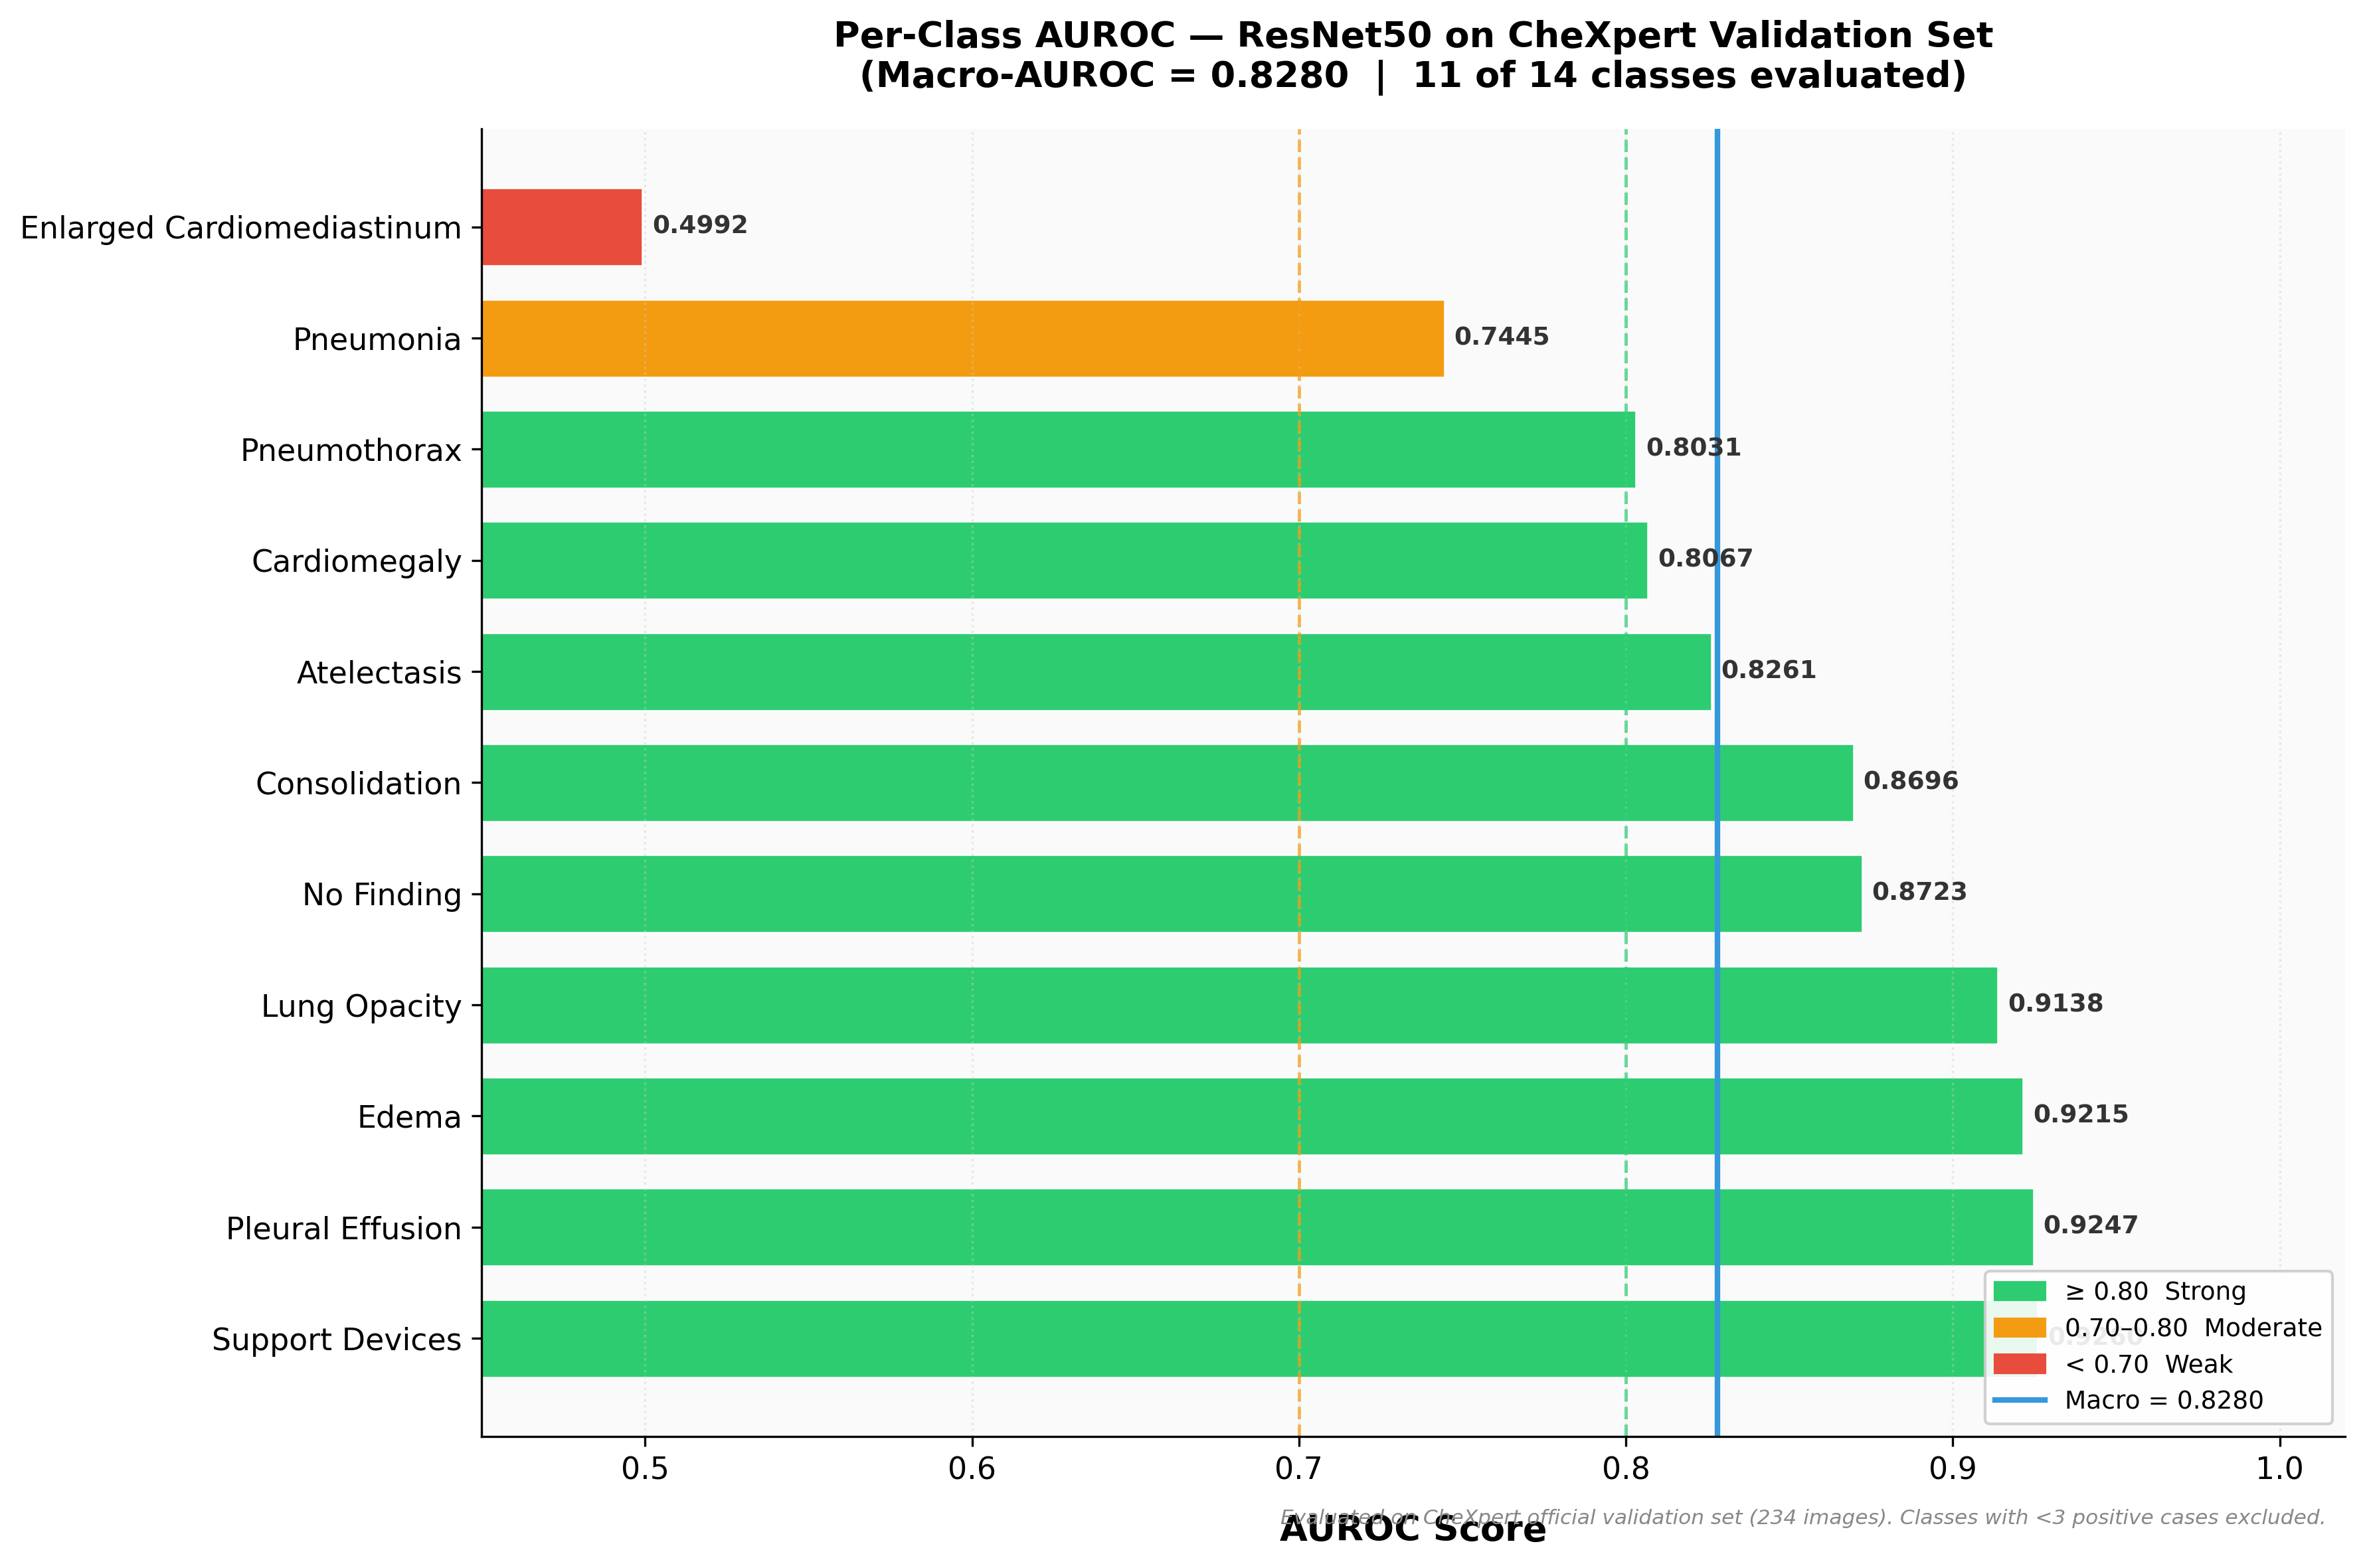

✔  Saved → /kaggle/working/fig_per_class_auroc_resnet50_300dpi.png



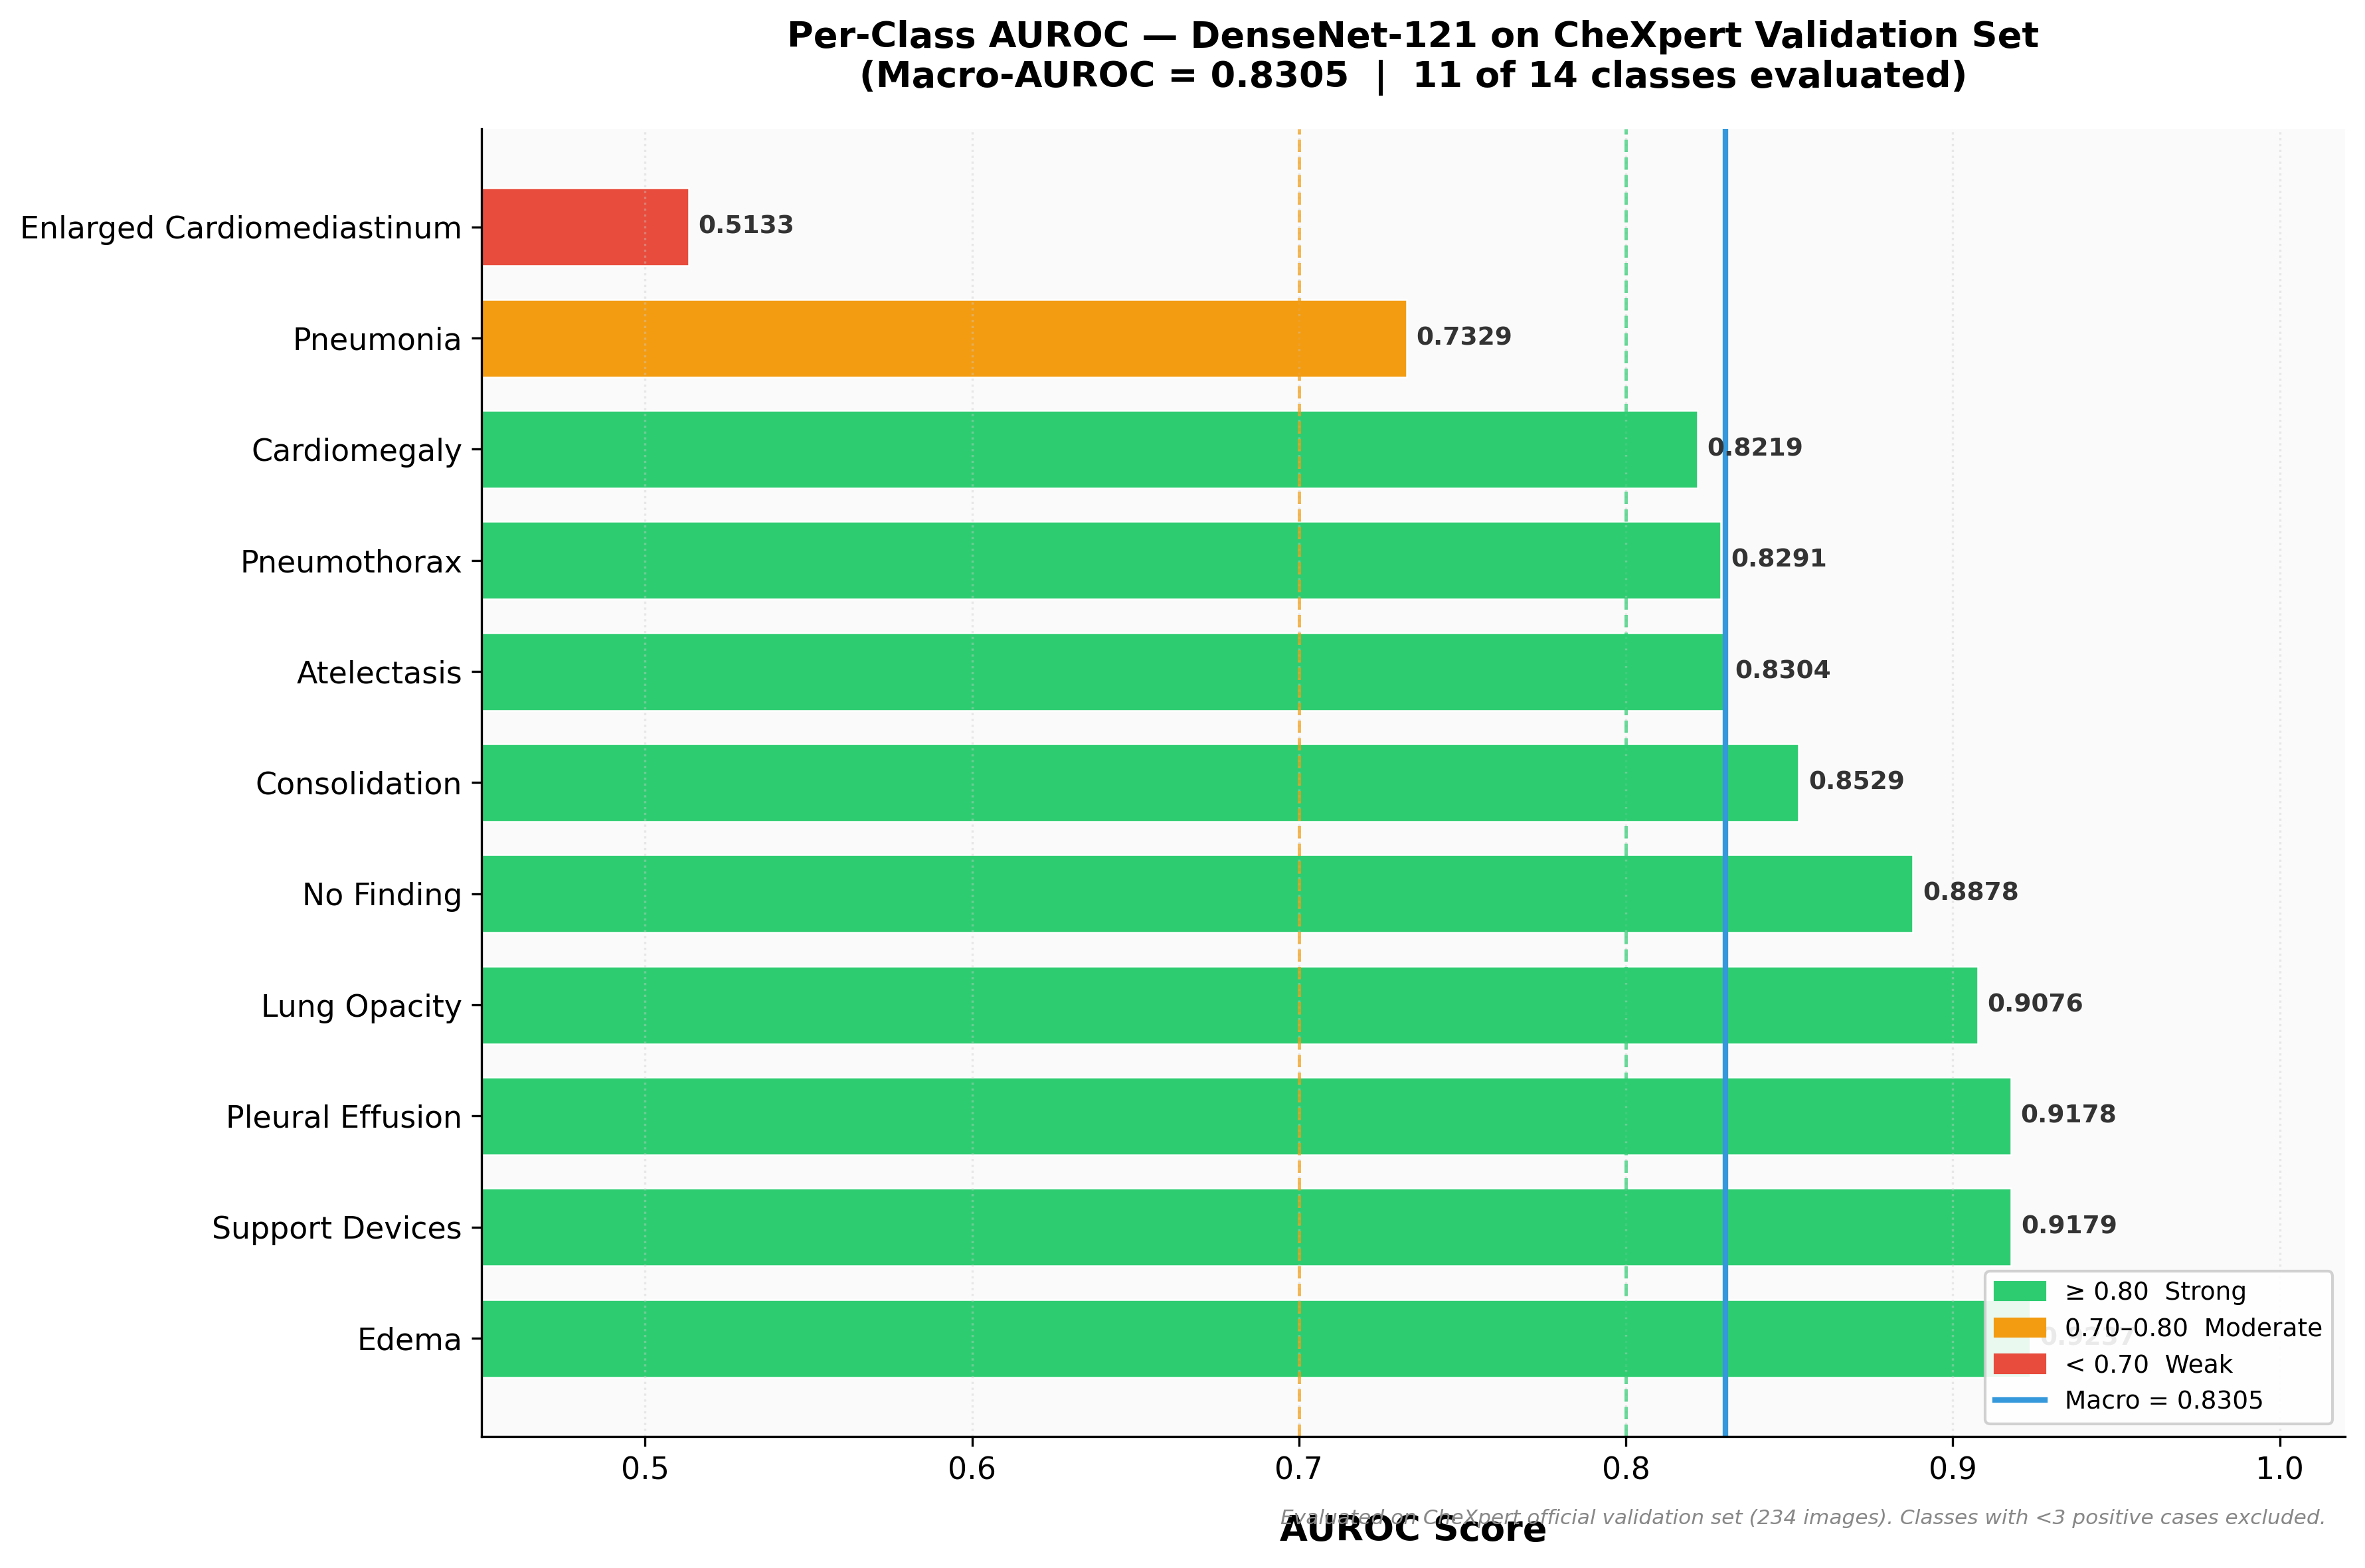

✔  Saved → /kaggle/working/fig_per_class_auroc_densenet121_300dpi.png



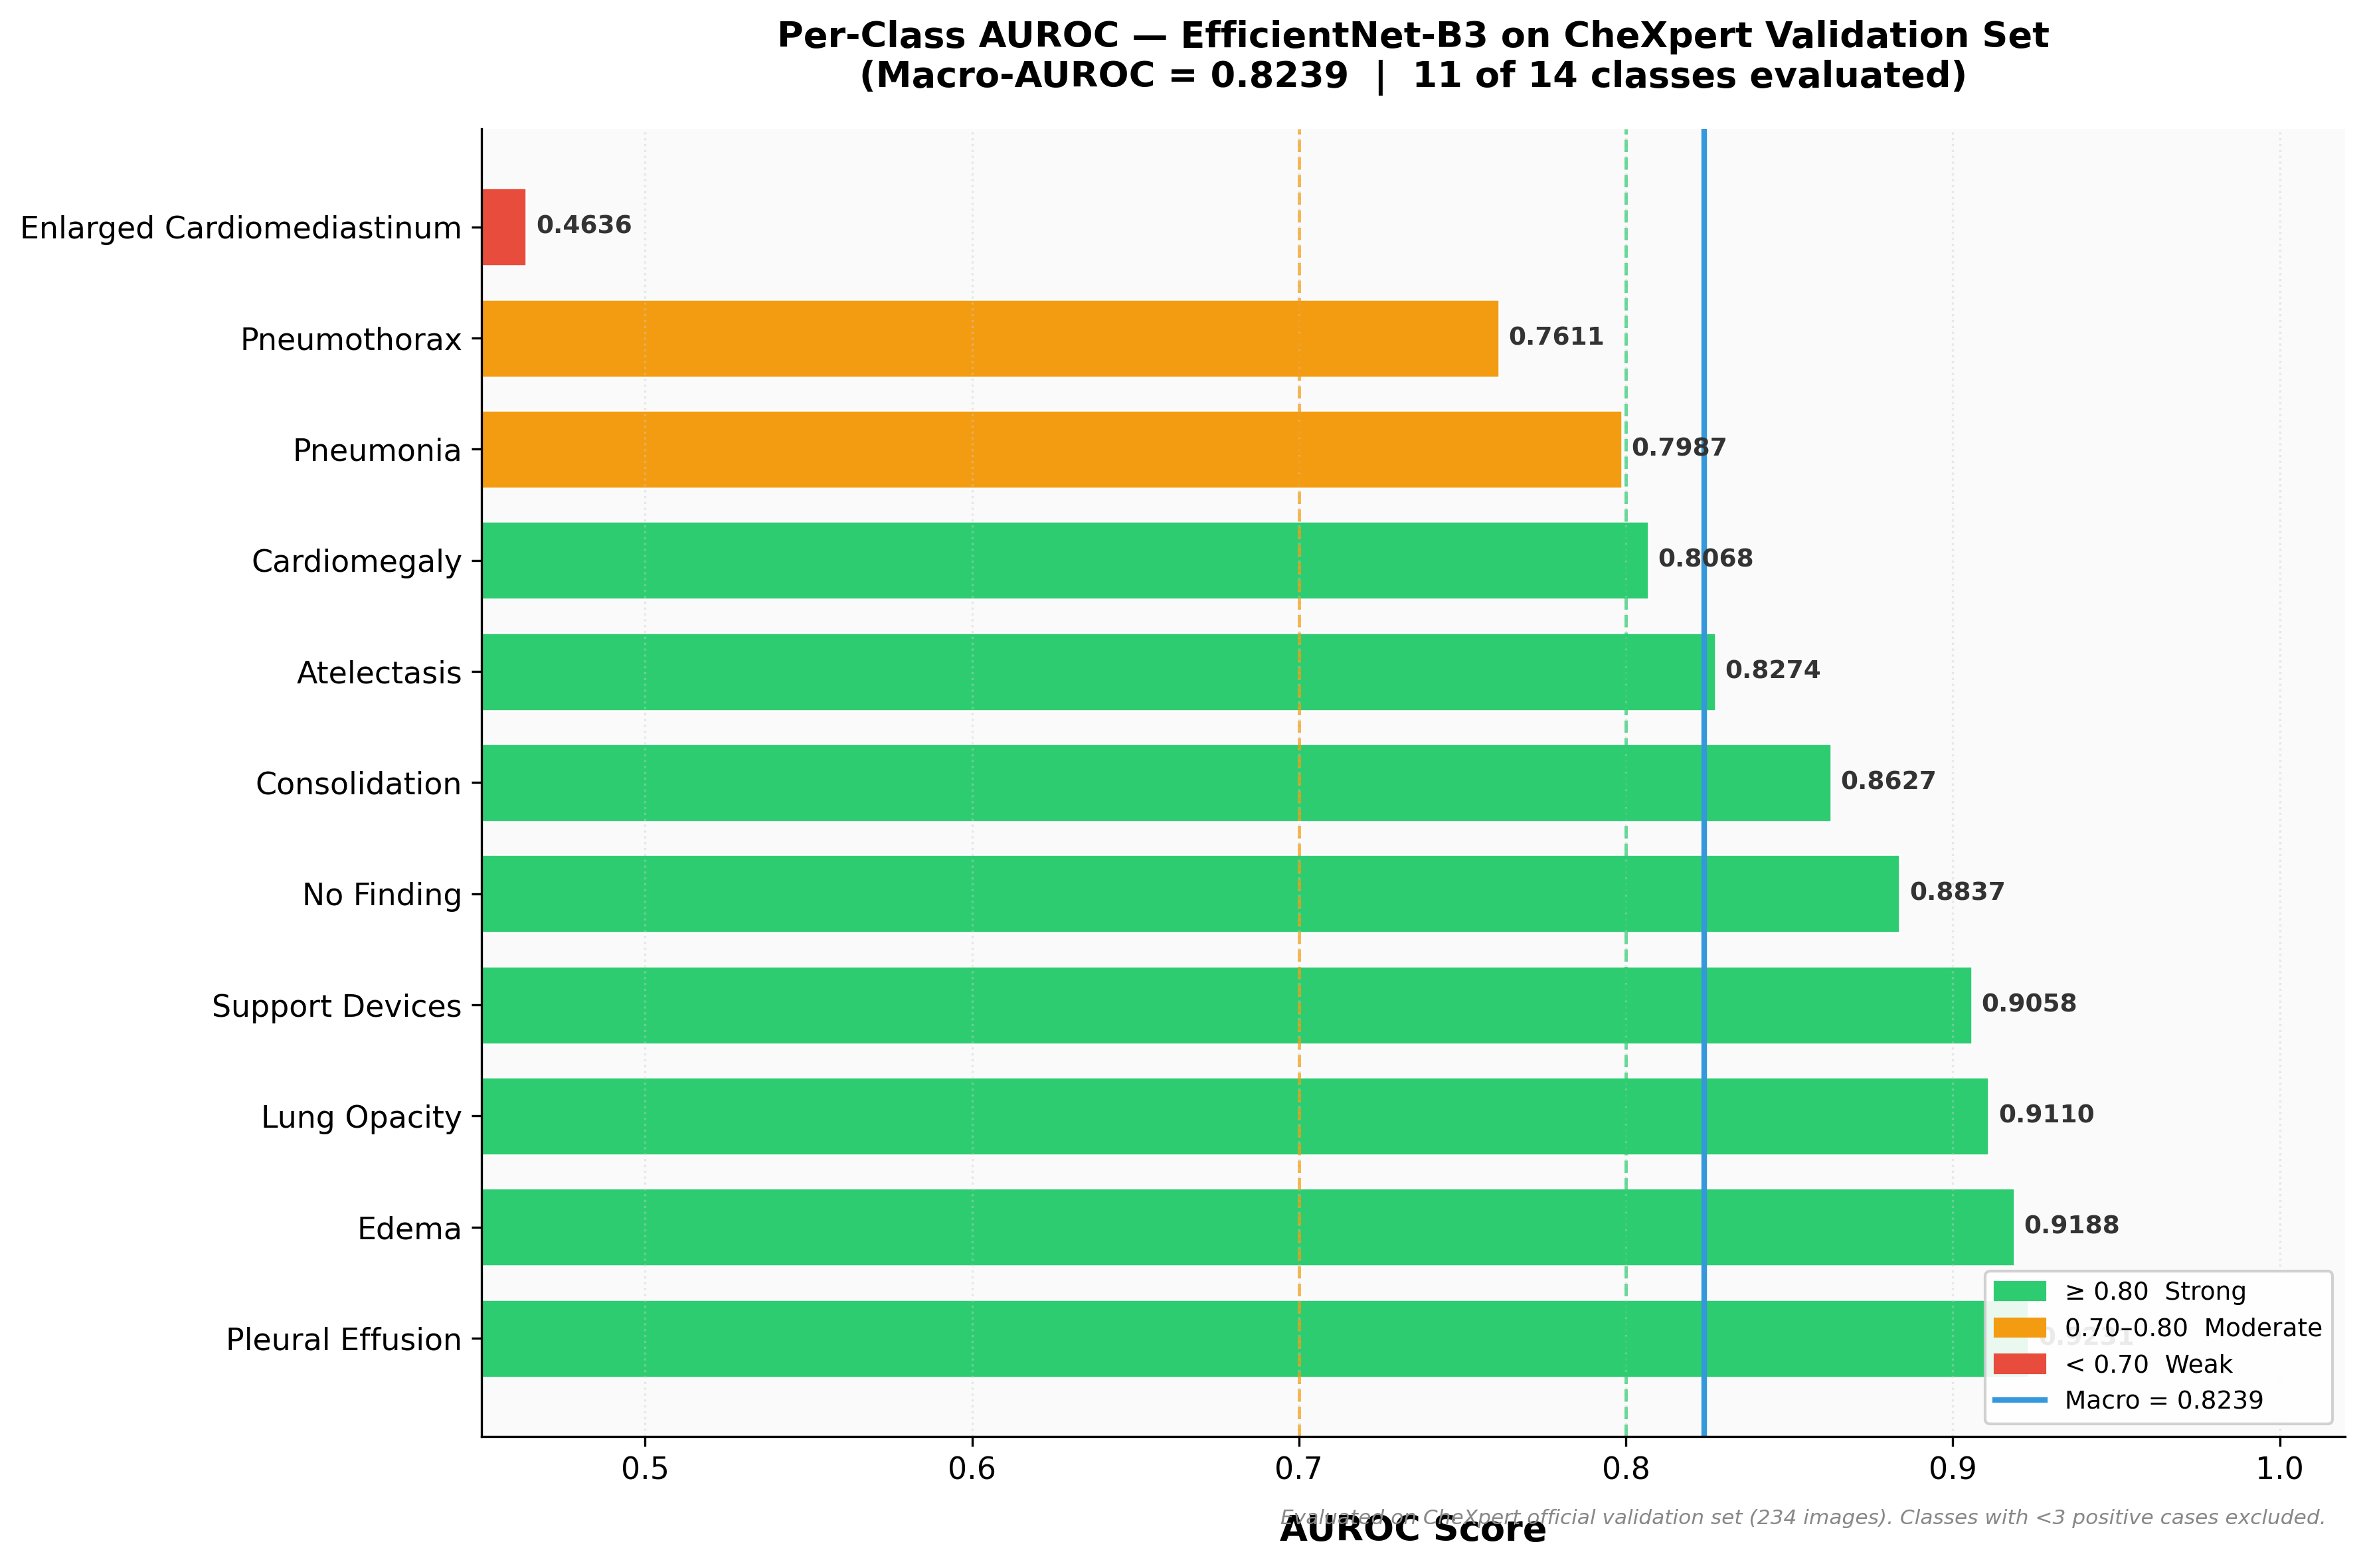

✔  Saved → /kaggle/working/fig_per_class_auroc_efficientnetb3_300dpi.png



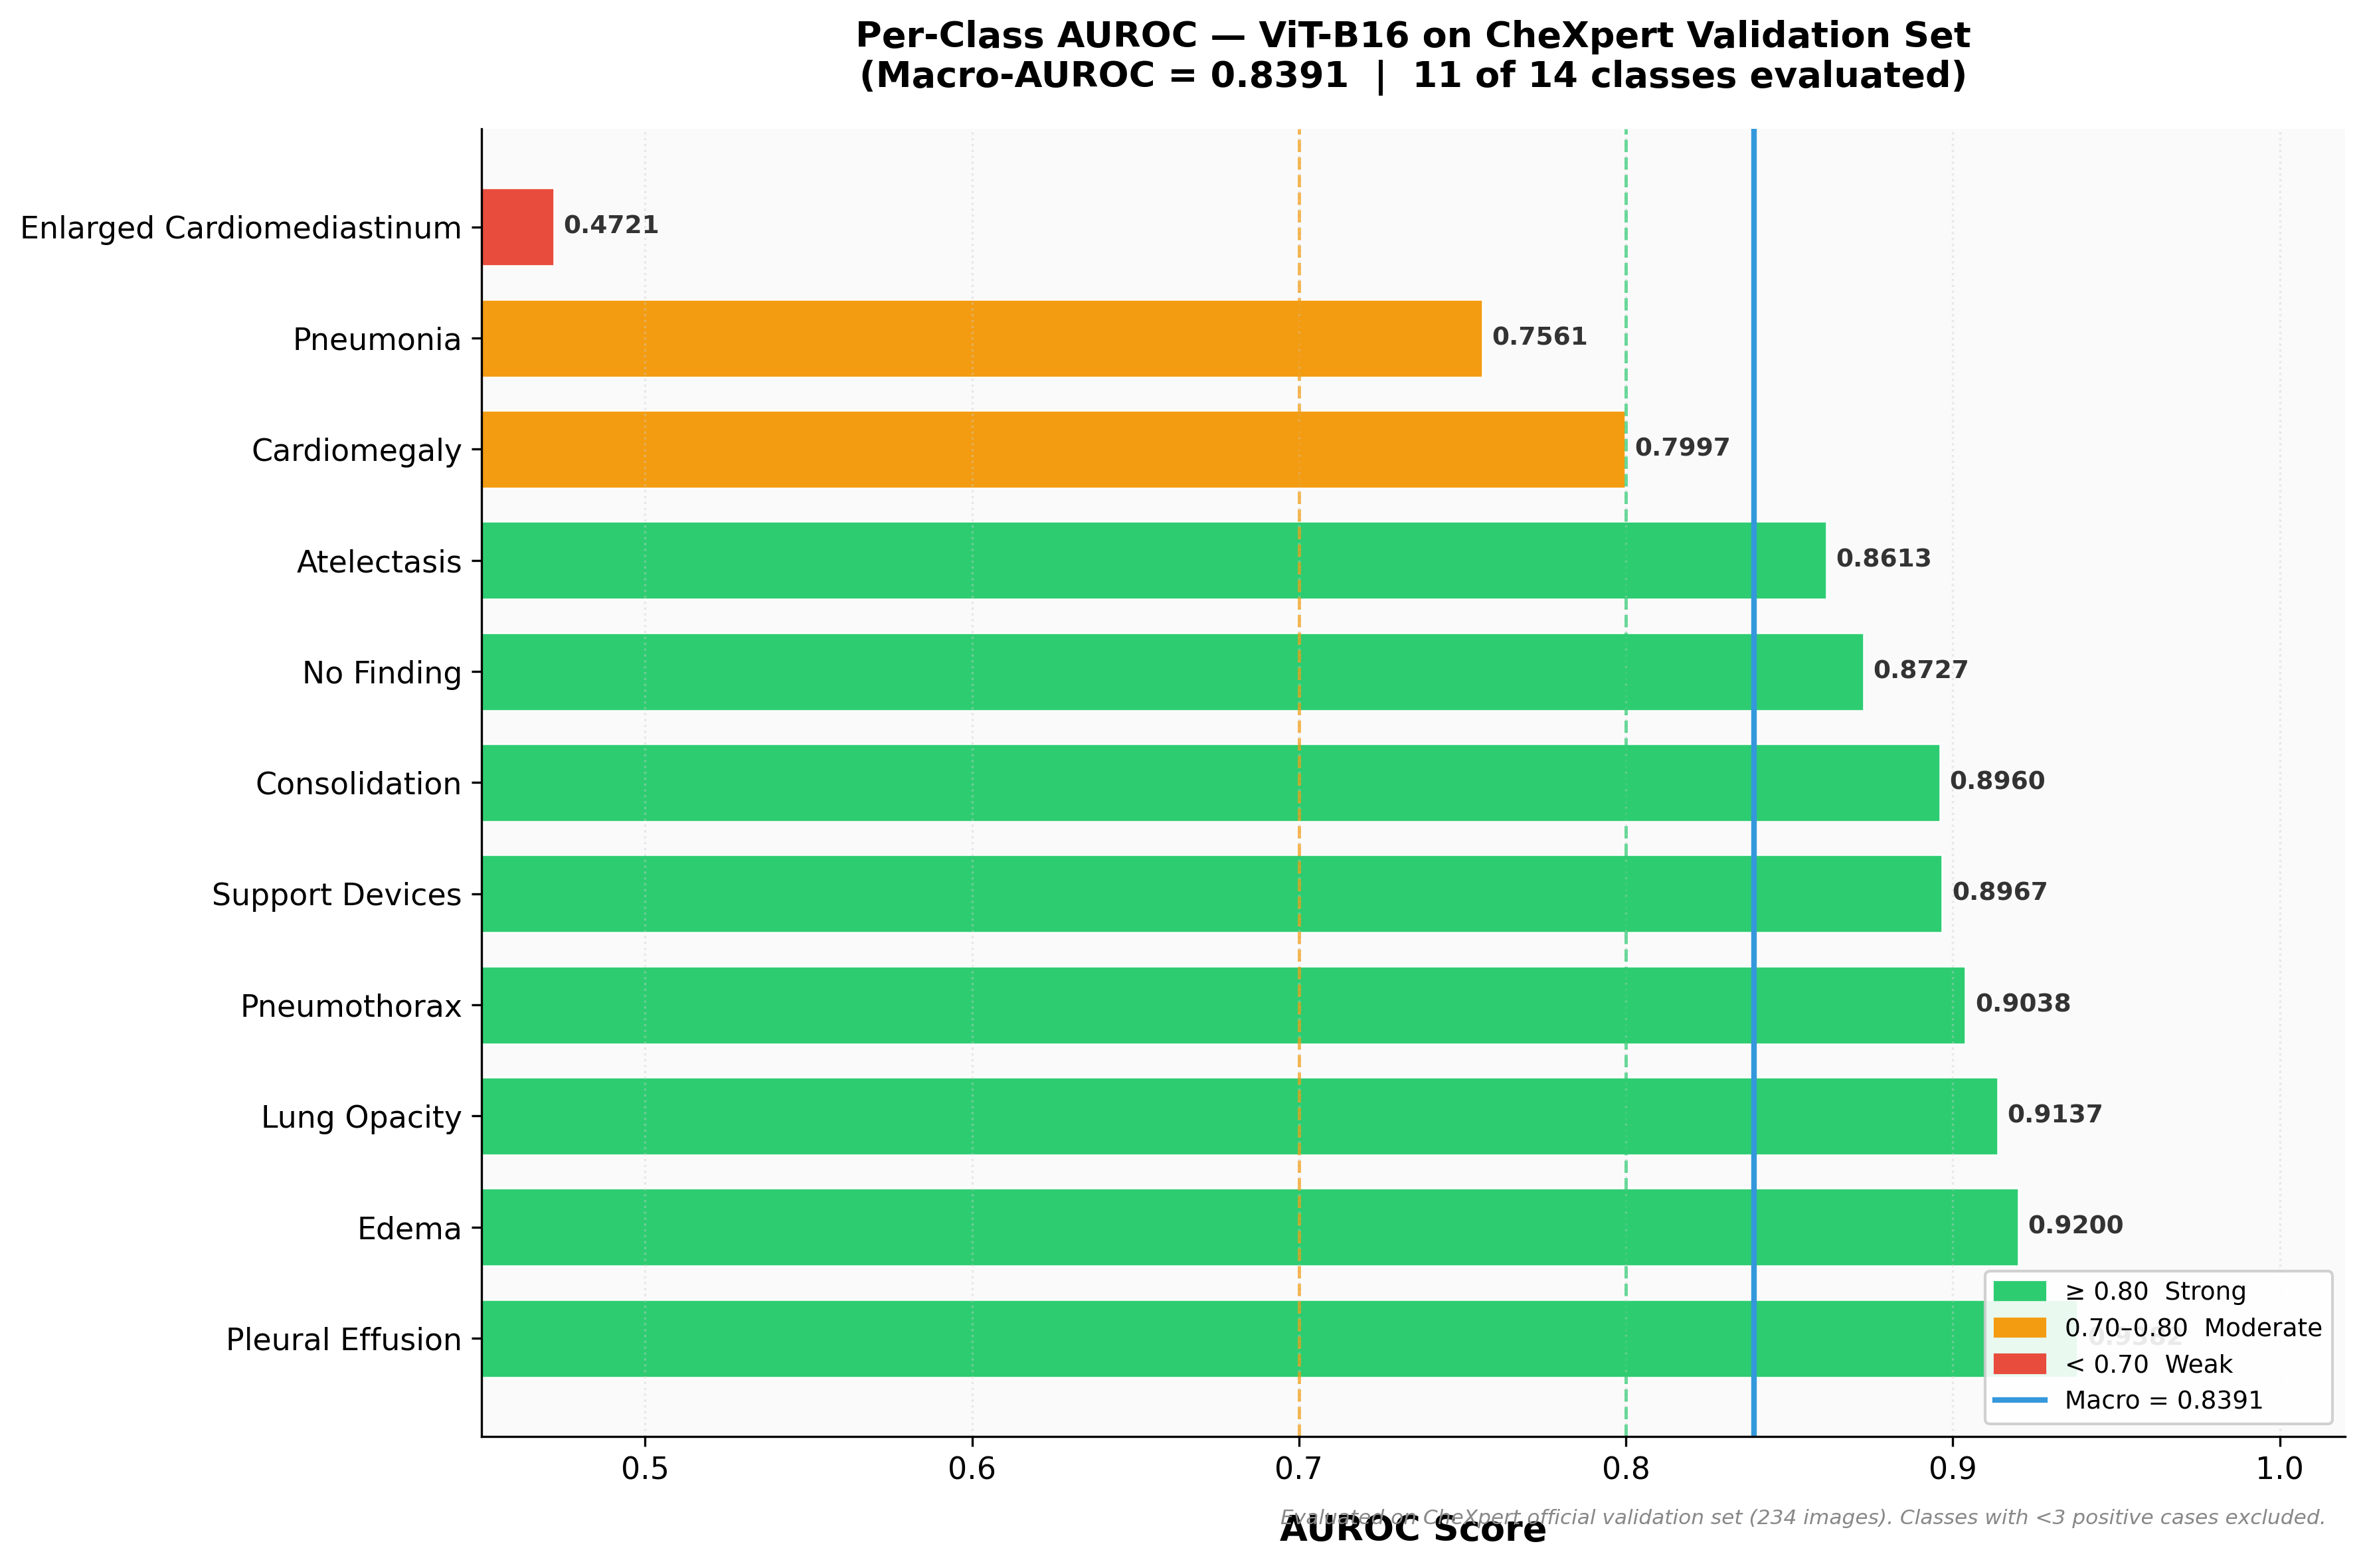

✔  Saved → /kaggle/working/fig_per_class_auroc_vitb16_300dpi.png



In [10]:
# ═══════════════════════════════════════════════
# CELL 9: VIZ 1 — Per-Class AUROC Bar Chart (All Models)
# 300 DPI, Thesis-Ready
# ═══════════════════════════════════════════════

for MODEL, results in ALL_RESULTS.items():

    valid_classes = {k: v for k, v in results['per_class'].items()
                     if v is not None}
    classes = list(valid_classes.keys())
    aurocs  = list(valid_classes.values())

    # Sort descending
    sorted_pairs   = sorted(zip(aurocs, classes), reverse=True)
    aurocs_sorted  = [x[0] for x in sorted_pairs]
    classes_sorted = [x[1] for x in sorted_pairs]

    # Color coding
    bar_colors = ['#2ecc71' if a >= 0.80 else
                  '#f39c12' if a >= 0.70 else
                  '#e74c3c' for a in aurocs_sorted]

    fig, ax = plt.subplots(figsize=(12, 8), dpi=300)
    fig.patch.set_facecolor('white')

    bars = ax.barh(classes_sorted, aurocs_sorted,
                   color=bar_colors, edgecolor='white',
                   linewidth=0.6, height=0.7)

    # Value labels on bars
    for bar, val in zip(bars, aurocs_sorted):
        ax.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', ha='left',
                fontsize=9, fontweight='bold', color='#333333')

    # Reference lines
    ax.axvline(0.80, color='#2ecc71', linestyle='--', lw=1.2,
               alpha=0.7, label='0.80 — Strong')
    ax.axvline(0.70, color='#f39c12', linestyle='--', lw=1.2,
               alpha=0.7, label='0.70 — Moderate')
    ax.axvline(results['macro'], color='#3498db',
               linestyle='-', lw=2.0,
               label=f'Macro-AUROC = {results["macro"]:.4f}')

    # Styling
    ax.set_xlabel('AUROC Score', fontsize=13, fontweight='bold', labelpad=10)
    ax.set_title(f'Per-Class AUROC — {MODEL} on CheXpert Validation Set\n'
                 f'(Macro-AUROC = {results["macro"]:.4f}  |  '
                 f'{len(valid_classes)} of {NUM_CLASSES} classes evaluated)',
                 fontsize=13, fontweight='bold', pad=15)
    ax.set_xlim(0.45, 1.02)
    ax.set_facecolor('#fafafa')
    ax.grid(axis='x', alpha=0.4, linestyle=':', color='#cccccc')
    ax.spines[['top', 'right']].set_visible(False)

    legend_handles = [
        mpatches.Patch(color='#2ecc71', label='≥ 0.80  Strong'),
        mpatches.Patch(color='#f39c12', label='0.70–0.80  Moderate'),
        mpatches.Patch(color='#e74c3c', label='< 0.70  Weak'),
        plt.Line2D([0], [0], color='#3498db', lw=2,
                   label=f'Macro = {results["macro"]:.4f}'),
    ]
    ax.legend(handles=legend_handles, loc='lower right',
              fontsize=9, framealpha=0.9)

    ax.text(0.99, -0.07,
            'Evaluated on CheXpert official validation set (234 images). '
            'Classes with <3 positive cases excluded.',
            ha='right', va='bottom', transform=ax.transAxes,
            fontsize=7.5, color='#888888', style='italic')

    plt.tight_layout()

    # Save with model name in filename
    slug  = MODEL.lower().replace("-", "").replace("/", "").replace(" ", "_")
    fname = f'/kaggle/working/fig_per_class_auroc_{slug}_300dpi.png'
    plt.savefig(fname, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"✔  Saved → {fname}\n")

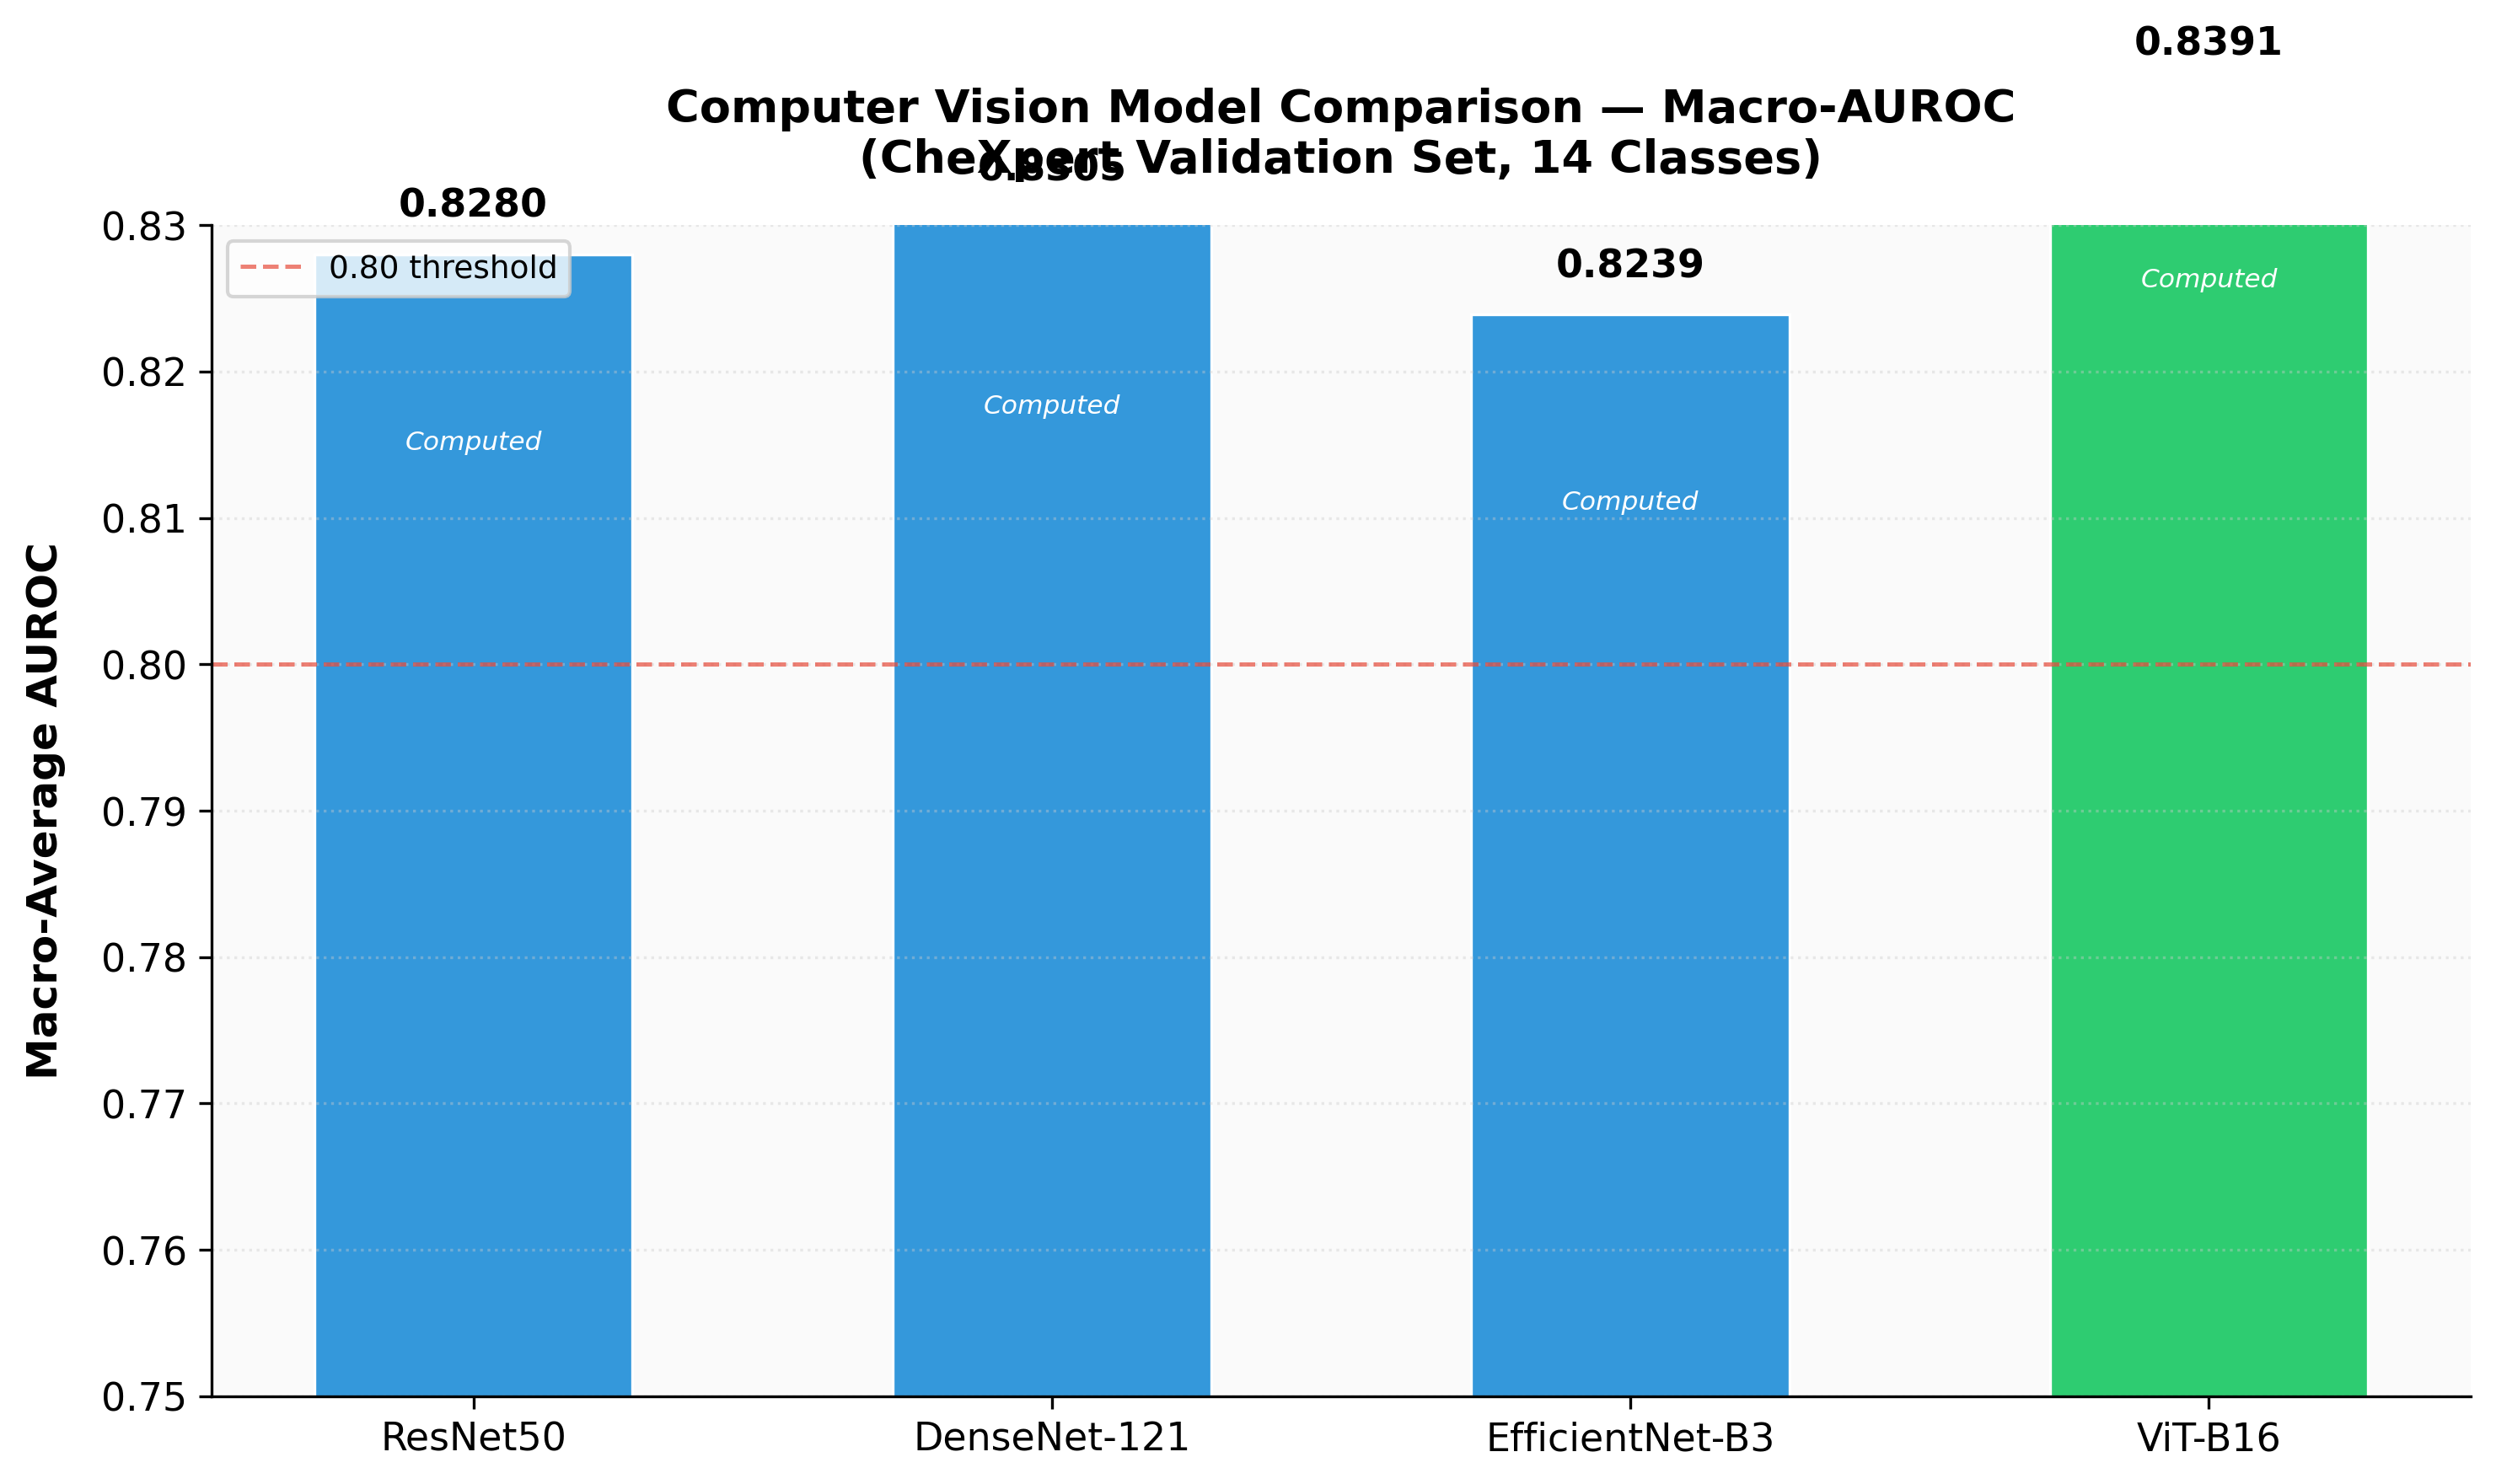

Saved → fig_model_comparison_300dpi.png


In [11]:
# ═══════════════════════════════════════════════
# CELL 10: VIZ 2 — 4-Model Macro-AUROC Comparison
# 300 DPI, Thesis-Ready
# ═══════════════════════════════════════════════

model_names = list(KNOWN_AUROC.keys())
macro_aucs  = []
sources     = []

for m in model_names:
    if m in ALL_RESULTS:
        macro_aucs.append(ALL_RESULTS[m]['macro'])
        sources.append('Computed')
    else:
        macro_aucs.append(KNOWN_AUROC[m])
        sources.append('Training log')

colors = ['#2ecc71' if a == max(macro_aucs) else '#3498db'
          for a in macro_aucs]

fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
fig.patch.set_facecolor('white')

bars = ax.bar(model_names, macro_aucs,
              color=colors, edgecolor='white',
              linewidth=0.8, width=0.55)

# Value labels
for bar, val, src in zip(bars, macro_aucs, sources):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + 0.002, f'{val:.4f}',
            ha='center', va='bottom',
            fontsize=11, fontweight='bold')
    ax.text(bar.get_x() + bar.get_width()/2,
            val - 0.012, src,
            ha='center', va='top',
            fontsize=7.5, color='white', style='italic')

# Best model annotation
best_idx = macro_aucs.index(max(macro_aucs))
ax.annotate('Best Model\n(Selected for XAI)',
            xy=(best_idx, max(macro_aucs)),
            xytext=(best_idx + 0.5, max(macro_aucs) + 0.015),
            arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.5),
            fontsize=9, color='#e74c3c', fontweight='bold')

ax.set_ylim(0.75, 0.83)
ax.set_ylabel('Macro-Average AUROC', fontsize=12,
              fontweight='bold', labelpad=10)
ax.set_title('Computer Vision Model Comparison — Macro-AUROC\n'
             '(CheXpert Validation Set, 14 Classes)',
             fontsize=13, fontweight='bold', pad=15)
ax.axhline(0.80, color='#e74c3c', linestyle='--',
           lw=1.2, alpha=0.7, label='0.80 threshold')
ax.set_facecolor('#fafafa')
ax.grid(axis='y', alpha=0.4, linestyle=':', color='#cccccc')
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('/kaggle/working/fig_model_comparison_300dpi.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved → fig_model_comparison_300dpi.png")


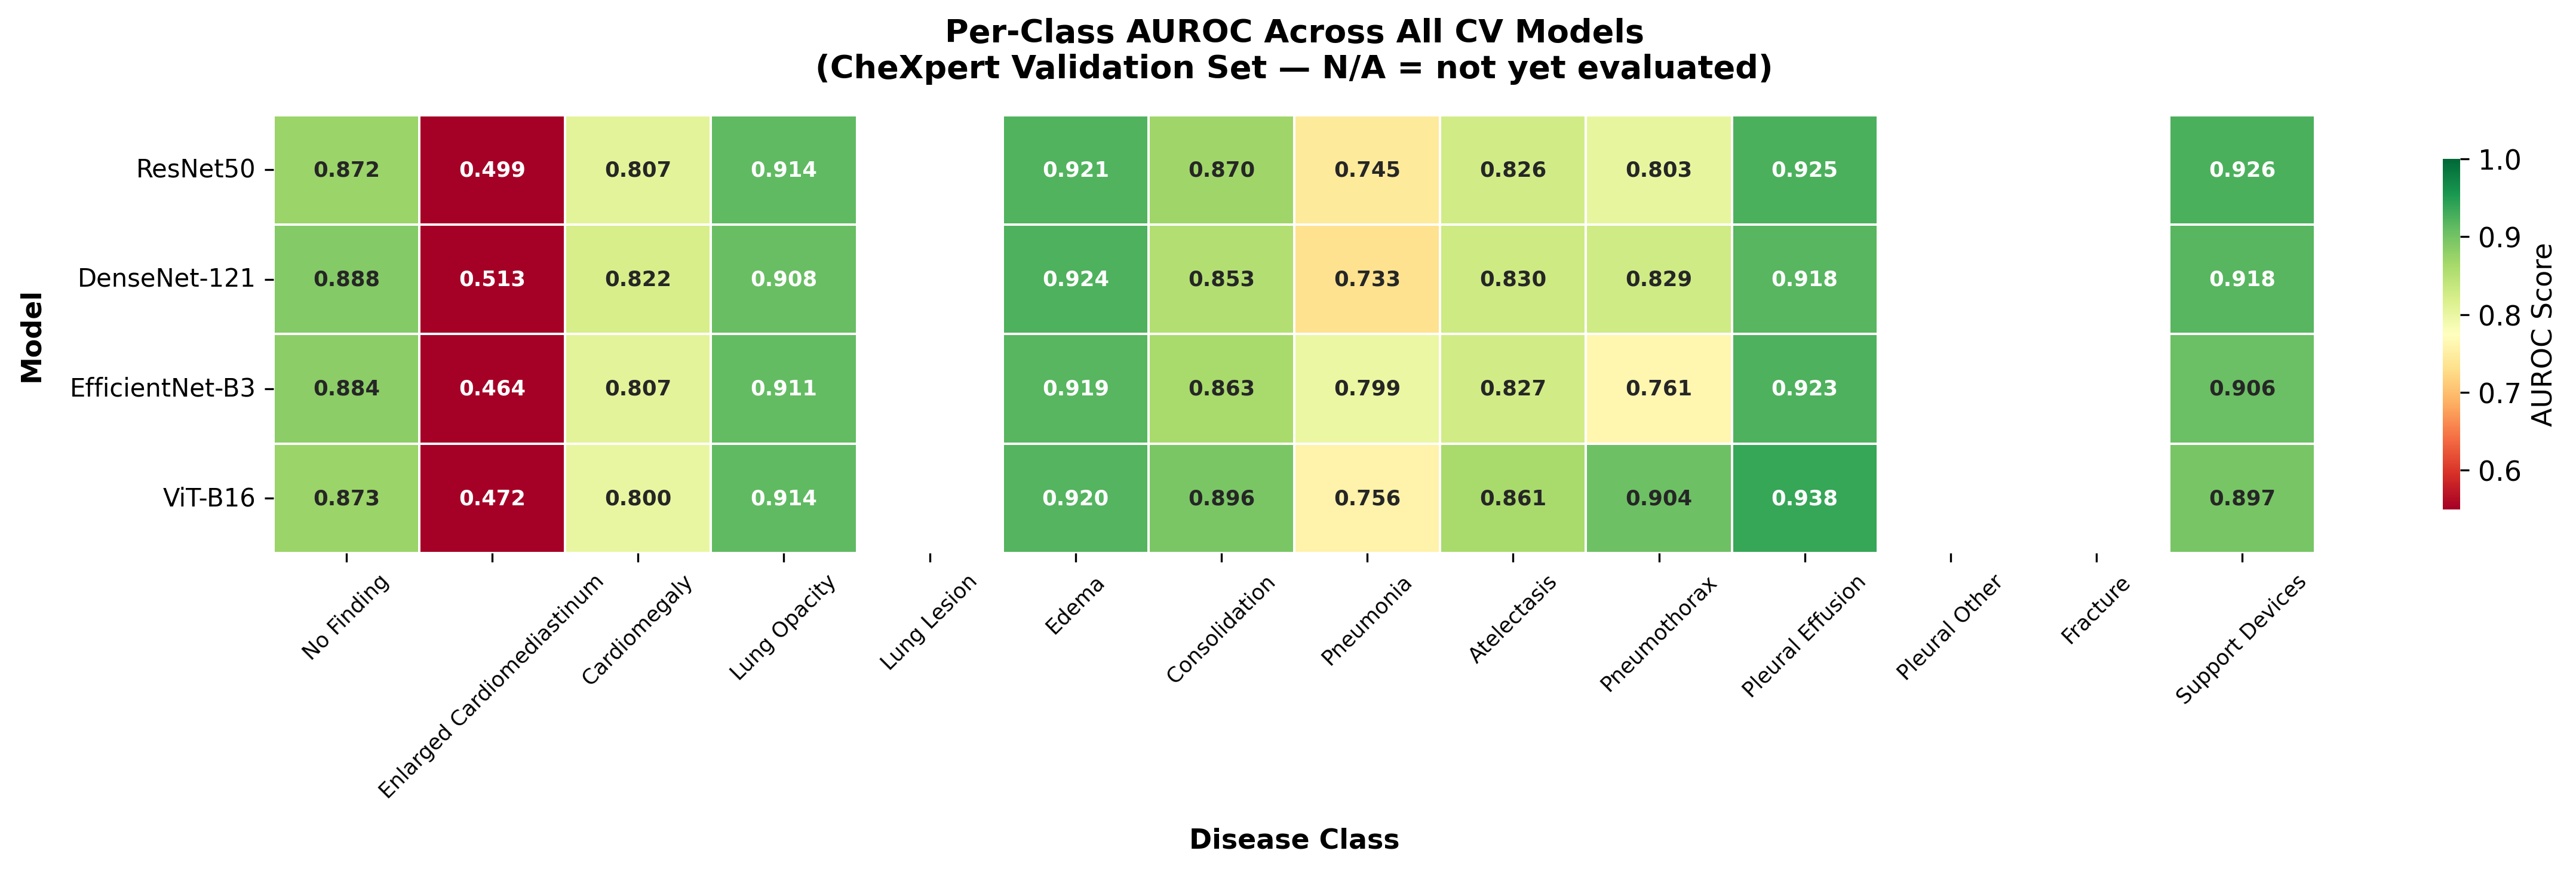

Saved → fig_auroc_heatmap_300dpi.png


In [12]:
# ═══════════════════════════════════════════════
# CELL 11: VIZ 3 — AUROC Heatmap (all models × all classes)
# 300 DPI, Thesis-Ready
# ═══════════════════════════════════════════════

# Build matrix: rows = models, cols = classes
heatmap_data = {}
for m in model_names:
    if m in ALL_RESULTS:
        row = [ALL_RESULTS[m]['per_class'].get(c) for c in LABEL_NAMES]
    else:
        # Fill with None — shown as grey in heatmap
        row = [None] * NUM_CLASSES
    heatmap_data[m] = row

df_heat = pd.DataFrame(heatmap_data, index=LABEL_NAMES).T.astype(float)

fig, ax = plt.subplots(figsize=(16, 5), dpi=300)
fig.patch.set_facecolor('white')

mask = df_heat.isnull()

sns.heatmap(df_heat,
            mask=mask,
            annot=True, fmt='.3f',
            cmap='RdYlGn',
            vmin=0.55, vmax=1.00,
            linewidths=0.5,
            linecolor='white',
            cbar_kws={'label': 'AUROC Score', 'shrink': 0.8},
            annot_kws={'size': 8.5, 'weight': 'bold'},
            ax=ax)

# Grey out cells with no data
sns.heatmap(df_heat,
            mask=~mask,
            annot=pd.DataFrame(
                [['N/A']*NUM_CLASSES for _ in model_names],
                index=model_names, columns=LABEL_NAMES
            ),
            fmt='',
            cmap=['#dddddd'],
            cbar=False,
            linewidths=0.5,
            linecolor='white',
            ax=ax)

ax.set_title('Per-Class AUROC Across All CV Models\n'
             '(CheXpert Validation Set — N/A = not yet evaluated)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Disease Class', fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel('Model', fontsize=11, fontweight='bold', labelpad=10)
ax.tick_params(axis='x', rotation=45, labelsize=8.5)
ax.tick_params(axis='y', rotation=0,  labelsize=10)

plt.tight_layout()
plt.savefig('/kaggle/working/fig_auroc_heatmap_300dpi.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved → fig_auroc_heatmap_300dpi.png")


In [13]:
# ═══════════════════════════════════════════════
# CELL 12: Download Links
# ═══════════════════════════════════════════════
from IPython.display import FileLink, display

outputs = [
    ('per_class_auroc_resnet50.csv',    'Per-class AUROC table (CSV)'),
    ('fig_per_class_auroc_300dpi.png',  'VIZ 1 — Per-class bar chart (300 DPI)'),
    ('fig_model_comparison_300dpi.png', 'VIZ 2 — Model comparison (300 DPI)'),
    ('fig_auroc_heatmap_300dpi.png',    'VIZ 3 — AUROC heatmap (300 DPI)'),
]

print("DOWNLOAD LINKS")
print("=" * 55)
for fname, label in outputs:
    fpath = f'/kaggle/working/{fname}'
    if os.path.exists(fpath):
        size_kb = os.path.getsize(fpath) / 1024
        print(f"\n  {label}  ({size_kb:.0f} KB)")
        display(FileLink(fname))
    else:
        print(f"\n  {fname} — not yet generated")
print("\nAlso available in Kaggle → Output tab (right panel)")


DOWNLOAD LINKS

  Per-class AUROC table (CSV)  (0 KB)


/kaggle/working/per_class_auroc_resnet50.csv


  fig_per_class_auroc_300dpi.png — not yet generated

  VIZ 2 — Model comparison (300 DPI)  (193 KB)


/kaggle/working/fig_model_comparison_300dpi.png


  VIZ 3 — AUROC heatmap (300 DPI)  (405 KB)


/kaggle/working/fig_auroc_heatmap_300dpi.png


Also available in Kaggle → Output tab (right panel)
